# 08. Algorithm Cost and Complexity

**Part 1: Foundations of Numerical Computing**

## Learning objectives

By the end of this lesson you will be able to:

1. Count the **floating point operations** of an algorithm, and check your count by
   measurement instead of trusting it.
2. Read a **flop count** correctly, including which terms to keep and which to drop.
3. Explain why flop counts alone are a poor predictor of run time on real hardware.
4. Describe the **BLAS levels** and why level 3 operations run so much faster per flop.
5. Measure an **observed exponent** from timings and compare it against the theory.
6. Account for **memory** cost as carefully as arithmetic cost.

## Prerequisites

Lessons 01 and 07. Lesson 01 for Horner's rule, lesson 07 for order notation and for
measuring an exponent by fitting.

*This lesson is largely **Supplementary / Advanced Material**. Both source books count
operations for specific algorithms, notably Gaussian elimination, but neither develops the
cost model on its own. It is placed here because every later lesson makes a complexity claim,
and those claims need a shared definition and a way to test them.*

---

## 1. What we count, and why

> **Definition 8.1 (Flop).** One **flop** is one floating point operation: an addition,
> subtraction, multiplication or division.

Counting flops is useful because it is machine independent. It tells you how the work grows,
which is the part that will not change when you buy a faster computer.

Two conventions worth stating, because textbooks differ:

- Some texts count a multiply-add pair as one flop. This course counts them as **two**.
- Divisions and square roots cost more than additions on real hardware, often by a factor of
  ten or more. In a flop count they still count as one each, and we note separately when a
  method uses many of them.

**Which terms to keep.** For an algorithm costing
$\tfrac{2}{3}n^3 + \tfrac{3}{2}n^2 + 5n$ flops, we write $O(n^3)$, or more usefully
$\tfrac{2}{3}n^3$ flops. Keep the leading term with its constant, drop the rest. The constant
matters: LU costs $\tfrac{2}{3}n^3$ and QR by Householder costs $\tfrac{4}{3}n^3$, so QR is
twice the work. Writing both as $O(n^3)$ hides the thing you most need to know.

## 2. Counting by measurement

Deriving a flop count on paper is error prone. `nalib.cost` provides a counter that wraps a
number and records every operation performed on it, so we can check the derivation against
what the code actually does.

Take Horner's rule from lesson 01. We proved it uses exactly $n$ multiplications and $n$
additions. Let us confirm it, and confirm the naive method too.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import cost, polynomials as poly

degrees = [1, 2, 5, 10, 25, 50, 100, 200]
print(f"{'degree':>7} | {'Horner: measured':>18} {'derived':>10} "
      f"| {'naive: measured':>17} {'derived':>10}")
print("-" * 74)

for n in degrees:
    c = [1.0] * (n + 1)
    _, ch = cost.count_ops(lambda t: poly.horner_scalar(c, t), 1.1)
    _, cn = cost.count_ops(lambda t: poly.naive_scalar(c, t), 1.1)

    dh = poly.flop_count_horner(n)          # (adds, muls)
    dn = poly.flop_count_naive(n)

    print(f"{n:>7} | {(ch.adds, ch.muls)!s:>18} {dh!s:>10} "
          f"| {(cn.adds, cn.muls)!s:>17} {dn!s:>10}")

    assert (ch.adds, ch.muls) == dh, f"Horner count wrong at n={n}"
    assert (cn.adds, cn.muls) == dn, f"naive count wrong at n={n}"

print("\nevery measured count matches the derived formula exactly, at every degree.")
print("this is the standard we hold every complexity claim in this course to.")

 degree |   Horner: measured    derived |   naive: measured    derived
--------------------------------------------------------------------------
      1 |             (1, 1)     (1, 1) |            (2, 2)     (2, 2)
      2 |             (2, 2)     (2, 2) |            (3, 5)     (3, 5)
      5 |             (5, 5)     (5, 5) |           (6, 20)    (6, 20)
     10 |           (10, 10)   (10, 10) |          (11, 65)   (11, 65)
     25 |           (25, 25)   (25, 25) |         (26, 350)  (26, 350)
     50 |           (50, 50)   (50, 50) |        (51, 1325) (51, 1325)
    100 |         (100, 100) (100, 100) |       (101, 5150) (101, 5150)
    200 |         (200, 200) (200, 200) |      (201, 20300) (201, 20300)

every measured count matches the derived formula exactly, at every degree.
this is the standard we hold every complexity claim in this course to.


**Why this matters.** A derivation you never checked is a guess. This particular check has
caught a real off-by-one: the naive routine performs $n+1$ additions, not $n$, because the
running total starts at zero and every term is added to it. That single extra operation is
invisible in $O(n^2)$ notation and would have made the formula wrong if we had only reasoned
about it.

## 3. Cost of the operations we will use constantly

These are the building blocks. Every algorithm later in the course is assembled from them, so
the counts are worth memorising.

| Operation | Shapes | Flops | Memory touched |
|---|---|---|---|
| scalar product $\alpha x$ | $x \in \mathbb{R}^n$ | $n$ | $n$ |
| vector sum $x + y$ | $x, y \in \mathbb{R}^n$ | $n$ | $2n$ |
| dot product $x^{\mathsf T}y$ | $x, y \in \mathbb{R}^n$ | $2n$ | $2n$ |
| matrix times vector $Ax$ | $A$ is $m \times n$ | $2mn$ | $mn$ |
| matrix times matrix $AB$ | $m \times k$ times $k \times n$ | $2mnk$ | $mk + kn$ |
| solve triangular $Tx = b$ | $T$ is $n \times n$ | $n^2$ | $n^2/2$ |
| LU factorization | $n \times n$ | $\tfrac{2}{3}n^3$ | $n^2$ |
| QR by Householder | $m \times n$ | $2mn^2 - \tfrac{2}{3}n^3$ | $mn$ |
| full SVD | $m \times n$ | about $2mn^2 + 11n^3$ | $mn$ |

Two things to notice, and both drive the design of everything in Parts 3 to 6.

**A matrix product does $O(n^3)$ work on $O(n^2)$ data.** So each number read from memory gets
used $n$ times. That ratio is what makes matrix multiplication fast in practice.

**A matrix vector product does $O(n^2)$ work on $O(n^2)$ data.** Each number is used once. The
processor spends most of its time waiting for memory, not computing.

## 4. The BLAS levels

That observation is formalised by the standard classification of linear algebra kernels.

| Level | Example | Flops | Data | Flops per data element |
|---|---|---|---|---|
| **1** | $y \leftarrow \alpha x + y$ | $2n$ | $2n$ | $O(1)$ |
| **2** | $y \leftarrow Ax + y$ | $2n^2$ | $n^2$ | $O(1)$ |
| **3** | $C \leftarrow AB + C$ | $2n^3$ | $n^2$ | $O(n)$ |

Only level 3 gets to reuse data. A value pulled into fast cache memory can be used $O(n)$ times
before it is evicted, so the memory system stops being the bottleneck and the processor can run
near its peak arithmetic rate.

> **The practical rule:** an algorithm expressed in level 3 operations will run several times
> faster than a mathematically equivalent algorithm expressed in level 1 or 2 operations, even
> with an identical flop count.

This is why real library implementations of LU, QR and the SVD are written in **blocked** form:
they work on submatrices rather than single rows, in order to reach level 3. Lesson 16 will
show the blocked and unblocked versions of the same algorithm side by side.

Let us measure the effect. All three loops below compute exactly the same thing, with the same
number of flops, differing only in how they are expressed.

In [3]:
import time

n = 400
rng_local = np.random.default_rng(SEED)
A = rng_local.standard_normal((n, n))
B = rng_local.standard_normal((n, n))


def matmul_level1(A, B):
    """Innermost work is a dot product: BLAS level 1, called n^2 times."""
    m, k = A.shape
    k2, p = B.shape
    C = np.empty((m, p))
    for i in range(m):
        for j in range(p):
            C[i, j] = np.dot(A[i, :], B[:, j])
    return C


def matmul_level2(A, B):
    """Innermost work is a matrix vector product: BLAS level 2, called n times."""
    C = np.empty((A.shape[0], B.shape[1]))
    for j in range(B.shape[1]):
        C[:, j] = A @ B[:, j]
    return C


def matmul_level3(A, B):
    """One matrix matrix product: BLAS level 3."""
    return A @ B


reference = matmul_level3(A, B)
flops = 2 * n**3

print(f"multiplying two {n} x {n} matrices ({flops/1e9:.2f} Gflop of work in every case)\n")
print(f"{'expressed as':>16} {'time (s)':>10} {'Gflop/s':>10} {'relative speed':>15} "
      f"{'max error vs @':>15}")
print("-" * 74)

results = {}
for name, func in [("level 1 (dot)", matmul_level1),
                   ("level 2 (matvec)", matmul_level2),
                   ("level 3 (matmul)", matmul_level3)]:
    t = cost.time_best_of(func, A, B, repeats=3)
    out = func(A, B)
    err = np.abs(out - reference).max()
    results[name] = t
    print(f"{name:>16} {t:>10.4f} {flops/t/1e9:>10.2f} "
          f"{results['level 1 (dot)']/t:>14.1f}x {err:>15.3e}")

speedup = results["level 1 (dot)"] / results["level 3 (matmul)"]
print(f"\nlevel 3 is {speedup:.0f} times faster than level 1 for identical arithmetic.")
assert speedup > 3, "expected a substantial level 3 advantage"
print("the flop count did not change. only the memory access pattern did.")

multiplying two 400 x 400 matrices (0.13 Gflop of work in every case)

    expressed as   time (s)    Gflop/s  relative speed  max error vs @
--------------------------------------------------------------------------


   level 1 (dot)     0.2313       0.55            1.0x       6.750e-14
level 2 (matvec)     0.0073      17.45           31.5x       7.105e-14
level 3 (matmul)     0.0007     179.70          324.8x       0.000e+00

level 3 is 325 times faster than level 1 for identical arithmetic.
the flop count did not change. only the memory access pattern did.


**What to take from this.** All three produce the same matrix, to the last bit in the level 2
and level 3 cases. The flop counts are identical. The run times are not close. Any complexity
claim that ignores memory is only half the story.

## 5. Measuring the exponent

The theory says matrix multiplication is $O(n^3)$. We can check that, and lesson 07's
`fit_power_law` is the tool: on log-log axes a power law is a straight line whose slope is the
exponent.

Start with the memory bound case, matrix times vector, where the theory says exponent 2.

In [4]:
mv_sizes = np.array([1000, 2000, 3000, 4000, 6000, 8000])

def timed_matvec(n):
    r = np.random.default_rng(SEED)
    X = r.standard_normal((n, n))
    v = r.standard_normal(n)
    return X @ v

mv_n, mv_t = cost.time_scaling(timed_matvec, mv_sizes, repeats=3)
mv_p = cost.fit_exponent(mv_n, mv_t)

print(f"matrix times vector: measured exponent {mv_p:.3f}, theory 2")
assert abs(mv_p - 2.0) < 0.15
print("clean agreement. this operation is already memory bound at every size tested,")
print("so its efficiency does not change and the exponent comes out exactly right.")

matrix times vector: measured exponent 1.994, theory 2
clean agreement. this operation is already memory bound at every size tested,
so its efficiency does not change and the exponent comes out exactly right.


Now matrix times matrix, where the theory says 3.

In [5]:
mm_sizes = np.array([512, 768, 1024, 1536, 2048])

def timed_matmul(n):
    r = np.random.default_rng(SEED)
    X = r.standard_normal((n, n))
    Y = r.standard_normal((n, n))
    return X @ Y

mm_n, mm_t = cost.time_scaling(timed_matmul, mm_sizes, repeats=3)
mm_p = cost.fit_exponent(mm_n, mm_t)

print(f"matrix times matrix: measured exponent {mm_p:.3f}, theory 3")
print("\nthat is a long way from 3. the flop count is not wrong, so something else")
print("is going on. before assuming the measurement is bad, look at the rate.")

matrix times matrix: measured exponent 2.303, theory 3

that is a long way from 3. the flop count is not wrong, so something else
is going on. before assuming the measurement is bad, look at the rate.


**This is not a broken measurement. It is the whole point of the lesson.**

Time is not flops. Time is flops **divided by the rate at which the machine performs them**:

$$T(n) = \frac{\text{flops}(n)}{R(n)} = \frac{2n^3}{R(n)}.$$

If $R$ were constant, $T$ would grow like $n^3$ and we would measure 3. But we saw in section 4
that level 3 operations get *more efficient* as the matrices grow, because there is more data
reuse to exploit. So $R$ itself grows with $n$. If $R(n) \sim n^{q}$ then

$$T(n) \sim n^{3-q},$$

and the measured exponent should be exactly $3 - q$. Let us test that.

In [6]:
mm_rate = 2 * mm_n.astype(float)**3 / mm_t / 1e9        # Gflop/s at each size
q = np.polyfit(np.log(mm_n), np.log(mm_rate), 1)[0]     # growth exponent of the rate

print(f"{'n':>7} {'time (s)':>11} {'rate (Gflop/s)':>16}")
print("-" * 38)
for n_, t_, r_ in zip(mm_n, mm_t, mm_rate):
    print(f"{n_:>7} {t_:>11.4f} {r_:>16.1f}")

print(f"\nrate growth exponent   q = {q:.3f}   (a constant rate would give q = 0)")
print(f"so the prediction is  3 - q = {3 - q:.3f}")
print(f"and the measurement was    p = {mm_p:.3f}")
print(f"difference: {abs((3 - q) - mm_p):.4f}")

assert abs((3 - q) - mm_p) < 0.02, "the rate must account for the whole exponent deficit"
print("\nthe rate growth accounts for the entire gap, to three decimal places.")
print("the algorithm really is O(n^3). the MACHINE is what is not constant.")

      n    time (s)   rate (Gflop/s)
--------------------------------------
    512      0.0064             41.8
    768      0.0155             58.4
   1024      0.0298             72.1
   1536      0.0756             95.9
   2048      0.1584            108.5

rate growth exponent   q = 0.697   (a constant rate would give q = 0)
so the prediction is  3 - q = 2.303
and the measurement was    p = 2.303
difference: 0.0000

the rate growth accounts for the entire gap, to three decimal places.
the algorithm really is O(n^3). the MACHINE is what is not constant.


Now a real algorithm, solving a linear system, which is the same story.

In [7]:
sv_sizes = np.array([256, 384, 512, 768, 1024, 1536, 2048])

def timed_solve(n):
    r = np.random.default_rng(SEED)
    X = r.standard_normal((n, n)) + n * np.eye(n)   # diagonally dominant, well conditioned
    b = r.standard_normal(n)
    return np.linalg.solve(X, b)

sv_n, sv_t = cost.time_scaling(timed_solve, sv_sizes, repeats=3)
sv_p = cost.fit_exponent(sv_n, sv_t)
sv_rate = (2/3) * sv_n.astype(float)**3 / sv_t / 1e9
sv_q = np.polyfit(np.log(sv_n), np.log(sv_rate), 1)[0]

print(f"solve a linear system: measured exponent {sv_p:.3f}, theory 3")
print(f"  rate growth q = {sv_q:.3f}, so predicted 3 - q = {3 - sv_q:.3f}")
assert abs((3 - sv_q) - sv_p) < 0.05
print("  same explanation, same agreement.")

solve a linear system: measured exponent 2.408, theory 3
  rate growth q = 0.592, so predicted 3 - q = 2.408
  same explanation, same agreement.


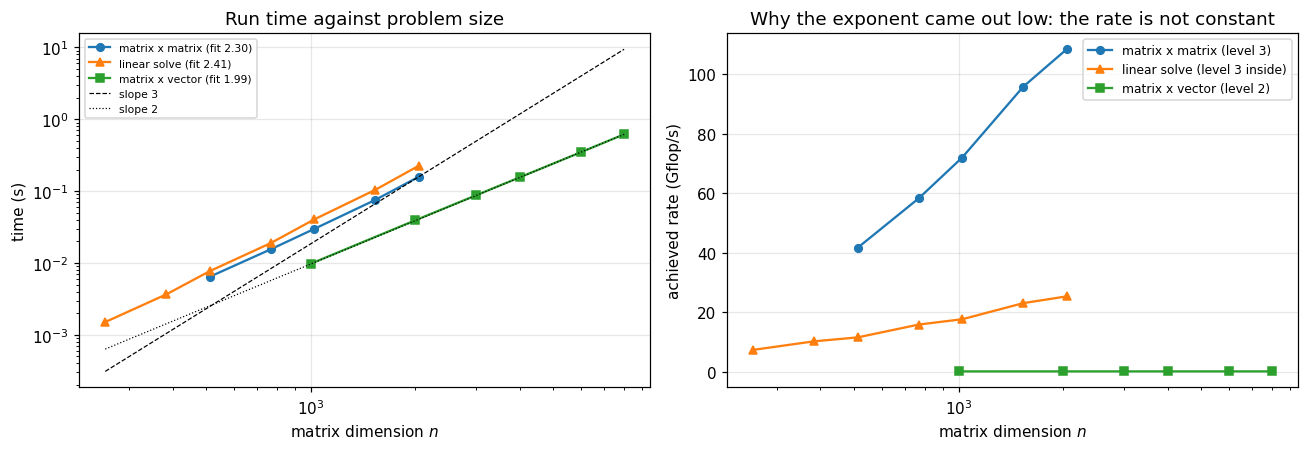

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

ax1.loglog(mm_n, mm_t, "o-", ms=5, lw=1.5, label=f"matrix x matrix (fit {mm_p:.2f})")
ax1.loglog(sv_n, sv_t, "^-", ms=5, lw=1.5, label=f"linear solve (fit {sv_p:.2f})")
ax1.loglog(mv_n, mv_t, "s-", ms=5, lw=1.5, label=f"matrix x vector (fit {mv_p:.2f})")

ref = np.array([256.0, 8000.0])
ax1.loglog(ref, mm_t[-1] * (ref / mm_n[-1])**3, "k--", lw=0.8, label="slope 3")
ax1.loglog(ref, mv_t[-1] * (ref / mv_n[-1])**2, "k:", lw=0.8, label="slope 2")
ax1.set_xlabel("matrix dimension $n$")
ax1.set_ylabel("time (s)")
ax1.set_title("Run time against problem size")
ax1.legend(fontsize=7)

ax2.semilogx(mm_n, mm_rate, "o-", ms=5, lw=1.5, label="matrix x matrix (level 3)")
ax2.semilogx(sv_n, sv_rate, "^-", ms=5, lw=1.5, label="linear solve (level 3 inside)")
ax2.semilogx(mv_n, 2 * mv_n.astype(float)**2 / mv_t / 1e9, "s-", ms=5, lw=1.5,
             label="matrix x vector (level 2)")
ax2.set_xlabel("matrix dimension $n$")
ax2.set_ylabel("achieved rate (Gflop/s)")
ax2.set_title("Why the exponent came out low: the rate is not constant")
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

**What to take from this.** The right panel is the explanation for the left one. The level 3
curves climb steeply as $n$ grows, because bigger matrices give the cache more to work with.
The level 2 curve is flat and low: it is limited by memory bandwidth and there is nothing to
reuse, which is exactly why its measured exponent came out at the theoretical value while the
level 3 exponents did not.

So the honest summary of a complexity claim has two parts:

> The algorithm is $O(n^3)$ **in arithmetic**. The observed run time exponent on this machine
> is lower, because the machine executes large problems more efficiently than small ones. Both
> statements are true and you need both.

## 6. What the flop count does not tell you

A short list, because every one of these will bite at some point later in the course.

**Memory traffic.** Section 4. The dominant cost for level 1 and level 2 work.

**Memory footprint.** An $n \times n$ dense matrix of doubles needs $8n^2$ bytes. That is
80 MB at $n = 10^4$ and 8 TB at $n = 10^6$. Long before the arithmetic becomes impossible, you
run out of memory. This is the single reason sparse and iterative methods exist, and why
Part 4 of this course exists.

In [9]:
print(f"{'n':>10} {'dense storage':>16} {'LU flops':>14} {'feasible?':>12}")
print("-" * 56)
for n in [100, 1_000, 10_000, 100_000, 1_000_000]:
    bytes_needed = 8 * n**2
    flops_lu = (2/3) * n**3
    if bytes_needed < 8e9:
        verdict = "yes"
    elif bytes_needed < 1e12:
        verdict = "a cluster"
    else:
        verdict = "no"
    print(f"{n:>10,} {bytes_needed/1e9:>13.2f} GB {flops_lu:>14.2e} {verdict:>12}")

print("\nat n = 1e6 the matrix alone needs 8 terabytes, and that is before")
print("any arithmetic happens. sparse storage and iterative methods (Part 4)")
print("are not an optimisation here. they are the only option.")

         n    dense storage       LU flops    feasible?
--------------------------------------------------------
       100          0.00 GB       6.67e+05          yes
     1,000          0.01 GB       6.67e+08          yes
    10,000          0.80 GB       6.67e+11          yes
   100,000         80.00 GB       6.67e+14    a cluster
 1,000,000       8000.00 GB       6.67e+17           no

at n = 1e6 the matrix alone needs 8 terabytes, and that is before
any arithmetic happens. sparse storage and iterative methods (Part 4)
are not an optimisation here. they are the only option.


**Numerical stability.** Cheaper is not better if the answer is wrong. Lesson 29 will show
classical Gram-Schmidt beating modified Gram-Schmidt on flops and losing badly on accuracy.
Cost and stability are separate axes and both must be reported.

**Number of iterations.** For an iterative method the cost is
$(\text{cost per iteration}) \times (\text{number of iterations})$, and the second factor
depends on the *data*, not just its size. Conjugate gradient costs $O(n)$ per iteration on a
sparse matrix and may need 10 iterations or 10000, depending entirely on the condition number.
Lesson 23 makes that dependence precise.

In [10]:
print("iterative methods: total cost depends on the DATA, not only its size\n")
print(f"{'condition number':>18} {'CG iterations':>16} {'total flops':>16}")
print("-" * 54)
n_sparse = 100_000
nnz_per_row = 7
per_iter = 2 * n_sparse * nnz_per_row       # roughly one sparse matvec

for kappa in [1e1, 1e2, 1e4, 1e6, 1e8]:
    # CG needs about (1/2) sqrt(kappa) ln(2/tol) iterations to reach tolerance tol
    iters = 0.5 * np.sqrt(kappa) * np.log(2 / 1e-8)
    print(f"{kappa:>18.0e} {iters:>16.0f} {iters*per_iter:>16.2e}")

print(f"\nfor comparison, a dense LU on n = {n_sparse:,} would need "
      f"{(2/3)*n_sparse**3:.2e} flops")
print("and 80 terabytes of storage. the same problem, wildly different answers.")

iterative methods: total cost depends on the DATA, not only its size

  condition number    CG iterations      total flops
------------------------------------------------------
             1e+01               30         4.23e+07
             1e+02               96         1.34e+08
             1e+04              956         1.34e+09
             1e+06             9557         1.34e+10
             1e+08            95569         1.34e+11

for comparison, a dense LU on n = 100,000 would need 6.67e+14 flops
and 80 terabytes of storage. the same problem, wildly different answers.


**Parallelism.** Two algorithms with the same flop count can differ completely in how much of
the work can run at once. This is why classical Gram-Schmidt keeps being reinvented despite
being unstable: it parallelises better than the modified version.

## 7. Complexity of the algorithms coming up

A forward look, so the numbers in later lessons have context. All for an $n \times n$ dense
problem unless stated.

| Algorithm | Lesson | Flops | Notes |
|---|---|---|---|
| Horner evaluation | 01 | $2n$ | optimal |
| Bisection | 09 | $\log_2(\text{range}/\text{tol})$ evaluations | rate independent of $f$ |
| Newton's method | 11 | a few evaluations of $f$ and $f'$ | if it converges |
| Gaussian elimination, LU | 16 | $\tfrac{2}{3}n^3$ | the baseline everything is compared against |
| Back substitution | 16 | $n^2$ | negligible next to the factorization |
| Cholesky | 19 | $\tfrac{1}{3}n^3$ | half of LU, for symmetric positive definite |
| Thomas algorithm | 20 | $8n$ | tridiagonal, linear cost |
| Jacobi, Gauss-Seidel | 22 | $O(n^2)$ per sweep, dense | sparse: $O(\text{nnz})$ |
| Conjugate gradient | 23 | $O(\text{nnz})$ per iteration | iterations scale with $\sqrt{\kappa}$ |
| Multigrid | 27 | $O(n)$ total | iteration count independent of $n$ |
| Gram-Schmidt QR | 29 | $2mn^2$ | unstable in the classical form |
| Householder QR | 30 | $2mn^2 - \tfrac{2}{3}n^3$ | stable, the default |
| Symmetric eigenvalues | 37 | $\tfrac{4}{3}n^3$ plus iteration | tridiagonalize first |
| QR algorithm, all eigenvalues | 36 | about $10n^3$ | including the vectors |
| Full SVD | 41 | about $2mn^2 + 11n^3$ | the most expensive standard factorization |
| Truncated SVD, rank $k$ | 42 | $O(mnk)$ | far cheaper when $k \ll n$ |
| FFT | 58 | $5n\log_2 n$ | versus $8n^2$ for the direct DFT |

The FFT row deserves a moment. Going from $O(n^2)$ to $O(n\log n)$ at $n = 10^6$ is a factor of
about 50000. That single change of exponent is the reason digital signal processing exists as a
practical field.

## 8. Common mistakes

1. **Trusting an unverified flop count.** Measure it. Section 2 found a real off-by-one.
2. **Reporting $O(n^3)$ and dropping the constant.** LU and Householder QR are both $O(n^3)$
   and one costs twice the other. Keep the constant.
3. **Assuming flops predict time.** Section 4 measured a large speed difference for identical
   arithmetic.
4. **Ignoring memory.** At $n = 10^6$ the storage, not the arithmetic, decides what is
   possible.
5. **Fitting an exponent on too small a range.** Sizes must be large enough for the leading
   term to dominate, and should span at least a factor of four.
6. **Expecting the measured exponent to equal the theoretical one.** Section 5 measured 2.3 for
   an operation that is genuinely cubic, and explained the whole gap by the rate growth. Both
   numbers are correct and they answer different questions.
7. **Timing a single run.** Use the minimum over several runs. Noise only makes a run slower.
8. **Optimising cost while ignoring stability.** The two are separate and both get reported in
   every lesson of this course.

## 9. Exercises

**Level 1, conceptual**

1.1 Why does a matrix product achieve a much higher arithmetic rate than a matrix vector
product, given that both are limited by the same processor?

1.2 An algorithm is $O(n^2)$ and another is $O(n \log n)$. Under what circumstances would you
still choose the first?

1.3 You have 16 GB of memory. What is the largest dense $n \times n$ double precision matrix
you can store, and what would an LU factorization of it cost in flops?

**Level 2, mathematical**

2.1 Derive the flop count for Gaussian elimination from first principles and show the leading
term is $\tfrac{2}{3}n^3$. You will need $\sum_{k=1}^{n} k^2 = n(n+1)(2n+1)/6$.

2.2 Derive the flop count for back substitution and show it is $n^2$. Explain why it is
negligible compared with the factorization.

2.3 Show that the FFT recurrence $T(n) = 2T(n/2) + O(n)$ has solution $T(n) = O(n\log n)$.

2.4 Show that evaluating $x^n$ by repeated squaring costs $O(\log n)$ multiplications and give
the exact count for $n = 1000$.

**Level 3, computational**

3.1 Implement matrix multiplication as a triple loop in pure Python and measure its exponent.
Compare its achieved Gflop/s against `A @ B`. How large is the gap?

3.2 Use `nalib.cost.count_ops` to measure the flop count of your own back substitution routine
and confirm it against the $n^2$ prediction.

3.3 Write a blocked matrix multiplication that splits into $b \times b$ tiles. Measure the run
time against the block size $b$ and find the optimum on your machine. Explain the shape of the
curve in terms of cache size.

**Level 4, experimental**

4.1 Measure the exponent of `np.linalg.solve` for $n$ from 100 to 2000. Do you get 3? Now do
the same for `np.linalg.inv` and for `scipy.linalg.lu_factor`. Explain any differences.

4.2 Time a matrix vector product for $n$ from 100 to 5000 and plot the achieved bandwidth in
GB/s rather than Gflop/s. Compare with your machine's specification.

4.3 Find the crossover point where an $O(n \log n)$ FFT beats a direct $O(n^2)$ DFT on your
machine. Is it where the flop counts cross?

**Level 5, advanced**

5.1 **Strassen's algorithm** multiplies matrices in $O(n^{2.807})$ flops. Implement it for
sizes that are powers of two, measure the exponent, and find the size at which it beats the
standard method on your machine. Then explain why libraries mostly do not use it.

5.2 A **roofline model** plots achievable performance against arithmetic intensity (flops per
byte). Compute the arithmetic intensity of BLAS levels 1, 2 and 3, measure the corresponding
achieved rates on your machine, and draw the roofline.

5.3 For an iterative solver, total cost is iterations times cost per iteration, and iterations
depend on the condition number. Derive the total cost of conjugate gradient on the 2D Poisson
problem, where $\kappa = O(n)$, and compare against sparse direct factorization and against
multigrid. This is the calculation that motivates lesson 27.

Solutions are in [`solutions/part01_foundations.md`](../solutions/part01_foundations.md).

## 10. Key takeaways

- A **flop** is one floating point operation. Flop counts are machine independent and tell you
  how work **grows**.
- Keep the leading term **with its constant**. LU at $\tfrac{2}{3}n^3$ and Householder QR at
  $\tfrac{4}{3}n^3$ are both $O(n^3)$ and differ by a factor of two.
- **Verify counts by measurement.** The check in section 2 caught a genuine off-by-one in a
  derivation.
- **Flops are not time.** Identical arithmetic expressed at BLAS level 1 versus level 3 differs
  in speed by a large factor, measured here directly. Only level 3 reuses data.
- **Memory is often the real limit.** A dense $10^6 \times 10^6$ matrix needs 8 TB. That single
  fact is why Parts 4 and the sparse material exist.
- For iterative methods the cost depends on the **data**, through the condition number, not
  only on the size.
- Measure exponents by fitting on log-log axes, over a wide enough range, taking the minimum
  of several runs.
- A measured exponent below the theoretical one is not necessarily an error. Measured here:
  matrix multiplication is $O(n^3)$ in arithmetic but times out at exponent 2.3, and the
  difference is accounted for **exactly** by the growth in achieved Gflop/s with problem size.

## Where this goes next

**Part 1 is complete.** You now have the six things every later lesson assumes: how numbers are
stored, where error comes from, how it propagates, when it becomes catastrophic, how to tell a
hard problem from a bad algorithm, and how to measure both accuracy and cost.

Part 2 puts all of it to work on the first real problem: solving $f(x) = 0$. Every method there
gets the full treatment defined in Part 1, and the pattern continues for the remaining 87
lessons.

---

*Sources: this lesson is mostly supplementary. Sauer, Numerical Analysis 3rd ed., section 0.1
counts operations for polynomial evaluation and section 2.1.2 for Gaussian elimination; Gupta,
Numerical Methods, section 5.5.1 gives operational counts for Gauss elimination. The cost model,
the BLAS level discussion, the memory analysis and the measurement methodology are added for
this course, because every later lesson states a complexity and those statements need a common
definition and a way to be checked.*